# Lab 5.1 Laplacian Image Editing

In this lab you will learn about the Laplacian pyramid representation and use it to smoothly blend together images.

In [53]:
!wget -q -nc -O cat_crop.jpg "https://www.dropbox.com/scl/fi/9lzgtveukfd3d4y287znv/cat_crop.jpg?rlkey=k6q6ni5ncvoadwidboyipoupk&dl=1"
!wget -q -nc -O pumpkin_crop.jpg "https://www.dropbox.com/scl/fi/b7ldrebwg7ruyaxk0dl2s/pumpkin_crop.jpg?rlkey=u7numvmmwvhaqqo81fy2dk9f2&dl=1"


In [54]:
import matplotlib.pyplot as plt
import numpy as np
from imageio.v3 import imread, imwrite
from skimage.transform import resize, rescale
from skimage.morphology import disk

In [55]:
levels = 5

img1 = imread('pumpkin_crop.jpg')
img2 = imread('cat_crop.jpg')

# load and resize images
pumpkin = img1.astype(np.float32) / 255.0
cat = resize(img2, pumpkin.shape[:2], anti_aliasing=True).astype(np.float32)

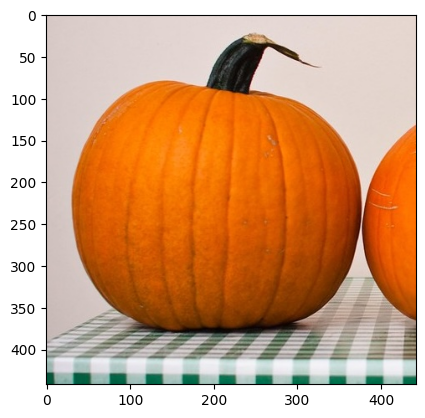

In [56]:
plt.imshow(pumpkin)

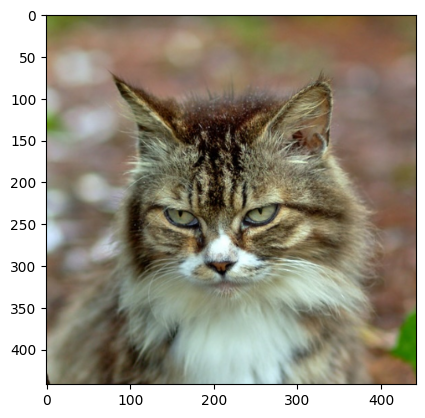

In [57]:
plt.imshow(cat)

## Mask

I will make a circular mask here that we will use later for combining the images.

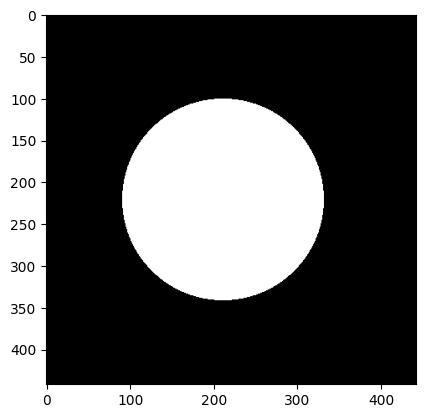

In [58]:
height, width = pumpkin.shape[:2]
y, x = np.ogrid[:height, :width]
center_y = height / 2
center_x = width / 2 - 10
radius = min(height, width) / 4 + 10
mask = ((x - center_x) ** 2 + (y - center_y) ** 2 <= radius ** 2).astype(np.float32)
plt.imshow(mask, cmap='gray')

## Gaussian pyramid

A **Gaussian pyramid** repeatedly smooths an image and reduces its size. Each level stores a lower-resolution version of the image, so coarse levels describe large-scale structure while fine levels preserve detail.

In [59]:
def make_gaussian_pyramid(image):
    gaussian_pyramid = [image]
    for i in range(levels - 1):
        gaussian_pyramid.append(rescale(gaussian_pyramid[-1],0.5,anti_aliasing=True,channel_axis=2))
    return gaussian_pyramid

In [60]:
def show_pyramid(pyramid,normalize=False):
    fig, axes = plt.subplots(1,levels,figsize=(7,6))
    for level, image in enumerate(pyramid):
        if normalize:
            image = image.copy()
            image -= image.min()
            image /= image.max()
        axes[level].imshow(image)
        axes[level].set_title(f'Level {level}')
        axes[level].axis('off')
    fig.tight_layout()

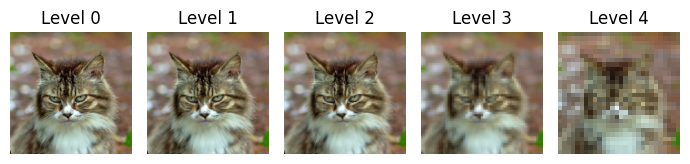

In [61]:
cat_gaussian_pyramid = make_gaussian_pyramid(cat)
show_pyramid(cat_gaussian_pyramid)

## Laplacian Pyramid

A **Laplacian pyramid** stores the detail removed between neighboring Gaussian levels:

$$L_i = G_i - \operatorname{up}(G_{i+1})$$

where $G_i$ is a Gaussian level and $\operatorname{up}(G_{i+1})$ is the next smaller level resized back to the current size. The smallest Gaussian image is kept as the final coarse level. Adding all Laplacian levels back together reconstructs the original image.

In [62]:
def make_laplacian_pyramid(gaussian_pyramid):
    laplacian_pyramid = []
    for level in range(levels - 1):
        expanded = resize(
            gaussian_pyramid[level + 1],
            gaussian_pyramid[level].shape[:2],
            anti_aliasing=False
        )
        laplacian_pyramid.append(gaussian_pyramid[level] - expanded)
    laplacian_pyramid.append(gaussian_pyramid[-1])
    return laplacian_pyramid

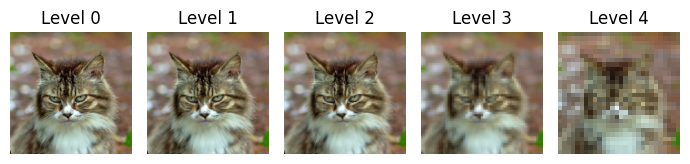

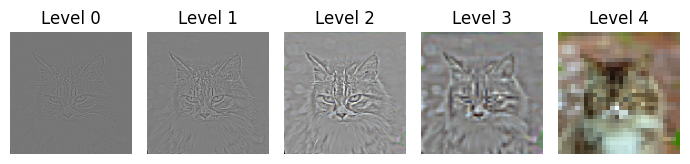

In [63]:
cat_laplacian_pyramid = make_laplacian_pyramid(cat_gaussian_pyramid)
show_pyramid(cat_gaussian_pyramid)
show_pyramid(cat_laplacian_pyramid,normalize=True)

## Exercises

1. Create function to reconstruct the original image from the Laplacian pyramid.

Starting with the last level in the Laplacian pyramid, resize it to the previous level's size and then add that level of the pyramid.  Continue to do this until you reach the bottom level.  Clip to $[0~1]$ range at the end (`np.clip`).

Explain why the Laplacian image reconstruction works.

In [64]:
def reconstruct_from_laplacian_pyramid(laplacian_pyramid):
    reconstructed = laplacian_pyramid[-1]
    # [last index of the laplacian pyramid (levels-1), 0] going in reverse order
    for level in range(levels-2, -1, -1):
        # Resize the image upwards
        expanded = resize(
            reconstructed,
            laplacian_pyramid[level].shape[:2],
            anti_aliasing=False
        )
        # Add it together instead of subtracting it
        reconstructed = laplacian_pyramid[level] + expanded
    return np.clip(reconstructed)

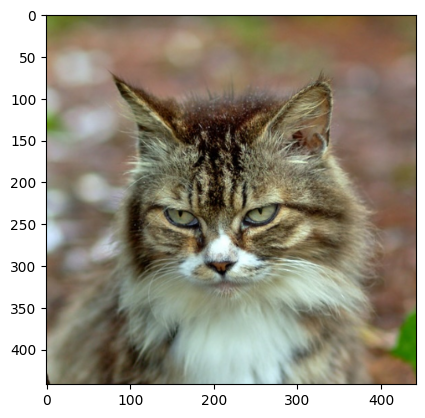

In [65]:
# Testing the reconstruction function
reconstructed_cat = reconstruct_from_laplacian_pyramid(cat_gaussian_pyramid)
plt.imshow(cat)

EXPLAINATION: This is just the exact opposite of the the building of the pyramid. Since the laplation pyramid stores the data that was "lost" when downsampling, we are able to use that to to undo the images created.

2. We want to blend the cat on top of the pumpkin.  First, do this using the provided "hard" mask, by computing $(1-\textrm{mask}) \textrm{pumpkin} + (\textrm{mask}) \textrm{cat}$.

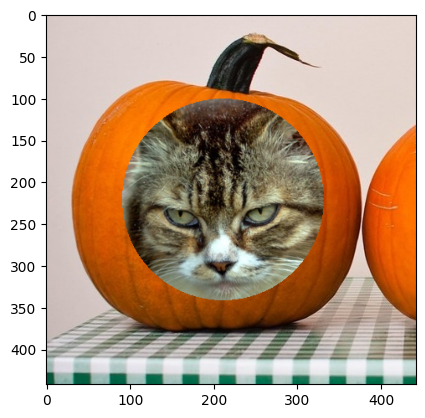

In [66]:
mask = mask[:, :, np.newaxis] # Make it 3d
cat_pumpkin_blend = (1-mask)*pumpkin + (mask)*cat

plt.imshow(cat_pumpkin_blend)

3. Now you will use the Laplacian pyramid for blending (this is the classic method of Burt and Adelson).  

Build the Laplacian pyramid for both the cat and the pumpkin and a Gaussian pyramid for the mask.

Then create a blended Laplacian pyramid by using the mask pyramid to blend together each level of the two Laplacian pyramids. (At each level, blend the two images using the mask at that level.)

Finally, reconstruct the blended Laplacian pyramid to achieve a smooth blending of the two images.

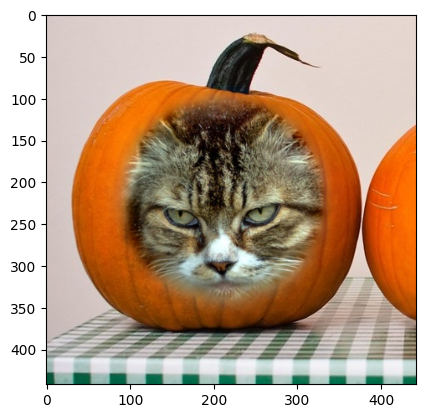

In [67]:
# Gaussian Pyramid for the Mask
gp_mask = make_gaussian_pyramid(mask)

# Laplacian Pyramid for Cat
gp_cat = make_gaussian_pyramid(cat)
lp_cat = make_laplacian_pyramid(gp_cat)

# Laplacian Pyramid for Pumpkin
gp_pump = make_gaussian_pyramid(pumpkin)
lp_pump = make_laplacian_pyramid(gp_pump)

# Blend Both
lp_blended = []
for i in range(len(lp_cat)):
  b = (1-gp_mask[i])*lp_pump[i] + (gp_mask[i])*lp_cat[i]
  lp_blended.append(b)

# Show the blended pyramid
# show_pyramid(lp_blended,normalize=True)
# Reconstruct the blended image
plt.imshow(reconstruct_from_laplacian_pyramid(lp_blended))

4. Why does the Laplacian blending produce a smoother result than the hard mask?

EXPLAINATION: I think it is because the blend mask is applied at every step in the pyramid.
This means that when a mask is applied to the cat, it is applied at different
"sizes" as we downsample. This along with the blurred mask allows for the cat
to fade in and the pumpkin to fade in at the exact same spot.